<a target="_blank" href="https://colab.research.google.com/github/Datacompintensive/HS-25-26/blob/master/GoodFeaturesToTrack/images_test.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My Drive/HS-25-26
except:
    IN_COLAB = False
    # Updating imports
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

Running on Local computer


In [2]:
import os
import numpy as np
import cv2
from matplotlib import pyplot as plt
import torch
import torchvision
import torch.nn.functional as F
import PIL.Image
import time

if IN_COLAB:
    data_dir = "img"
else:
    data_dir = "img"

if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Directory not found: {data_dir}")


Text(0.5, 1.0, '(b) Features')

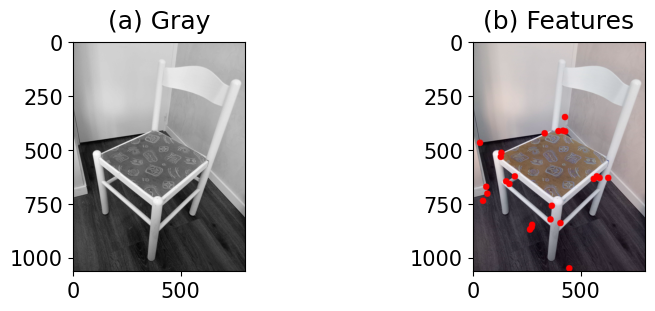

In [3]:
plt.rcParams.update({
    #"text.usetex": True,
    #"font.family": "serif",
    "font.size": 15,
    "figure.figsize": (8, 3)
})

img = cv2.imread(f"{data_dir}/chair.jpg")
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
 
corners = cv2.goodFeaturesToTrack(gray,25,0.01,10)
corners = corners.astype(np.int32)

for i in corners:
    x,y = i.ravel()
    cv2.circle(img,(x,y),15,255,-1)

fig, axs = plt.subplots(1, 2, layout="constrained")
axs[0].imshow(gray, cmap="gray")
axs[1].imshow(img)
axs[0].set_title("(a) Gray", pad=10)
axs[1].set_title("(b) Features", pad=10)

In [4]:
Nx2 = 5
Ny2 = 20
Nv2 = 20
emask = torch.zeros((2*Nv2,2*Nv2))
for i in range(0, Nx2):
    for j in range(-Ny2, Ny2):
        emask[Nv2+i,Nv2+j] = 1.0/(0.05*np.abs(j)+1)
emaskPIL = torchvision.transforms.ToPILImage()(emask)

Nmasks=10
allmasks=[]
for phi in np.arange(0.0,180.0,180.0/Nmasks):
    img = emaskPIL.rotate(phi, PIL.Image.NEAREST, expand = 0)
    rt = torchvision.transforms.ToTensor()(img)
    rt = rt-torchvision.transforms.ToTensor()(PIL.ImageOps.mirror(PIL.ImageOps.flip(img)))
    allmasks.append(rt)
allmasks = torch.cat(allmasks).view(len(allmasks),*emask.shape)

In [5]:
from typing import List
import numpy as np
import torch
import torch.nn.functional as F
import cv2
import time


def transform_images_with_masks(
    images: List[np.ndarray],
    masks: np.ndarray,
    device: str = "cpu"
) -> List[np.ndarray]:
    """
    Apply convolution-based transformation to grayscale images using a set of masks.

    Each image is convolved with all masks, then the squared responses are summed
    across channels and masks, normalized, and returned as a cv2-compatible image.

    Parameters
    ----------
    images : List[np.ndarray]
        List of grayscale images (H, W), dtype uint8 or float.
    masks : np.ndarray
        Array of masks with shape (N_masks, H_k, W_k).
    device : str, optional
        Torch device ("cpu" or "cuda"), by default "cpu".

    Returns
    -------
    List[np.ndarray]
        List of transformed images (H, W), dtype uint8.
    """

    # Convert masks to torch tensor
    #masks_t = torch.from_numpy(masks).float().to(device)  # (N, Hk, Wk)
    masks_t = masks.to(device)
    masks_t = masks_t.unsqueeze(1)  # (N, 1, Hk, Wk)

    transformed_images: List[np.ndarray] = []

    t1 = time.perf_counter()

    for img in images:
        # Ensure grayscale
        if img.ndim != 2:
            raise ValueError("All images must be grayscale (H, W).")

        # Convert to float tensor and normalize to [0,1]
        img_t = torch.from_numpy(img).float().to(device) / 255.0  # (H, W)

        # Replicate to 3 channels to match original logic
        img_t = img_t.unsqueeze(0).repeat(3, 1, 1)  # (3, H, W)

        # Reshape for conv2d
        img_t = img_t.view(3, 1, *img_t.shape[1:])  # (3, 1, H, W)

        # Convolution: output shape (3, N_masks, H_out, W_out)
        conv_out = F.conv2d(img_t, masks_t)

        # Compute squared energy sum across channels and masks
        energy = torch.sum(conv_out ** 2, dim=(0, 1))  # (H_out, W_out)

        # Normalize
        energy /= torch.max(energy) + 1e-12

        # Convert back to cv2 image (uint8)
        energy_np = (energy.cpu().numpy() * 255).astype(np.uint8)

        transformed_images.append(energy_np)

    t2 = time.perf_counter()
    print(f"Elapsed time: {t2 - t1:.4f} sec")

    return transformed_images

Elapsed time: 0.3781 sec


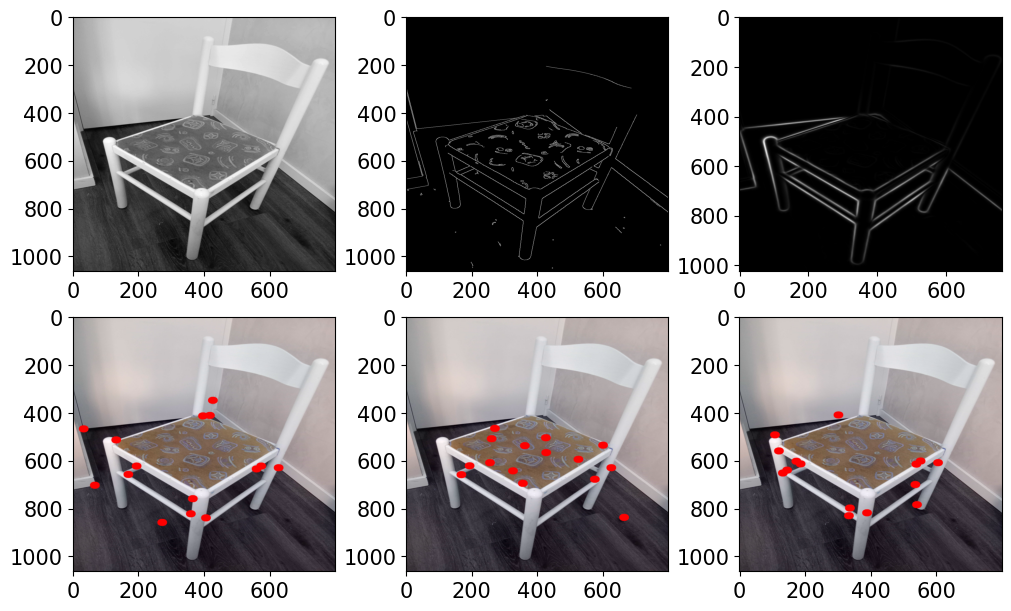

In [6]:
plt.rcParams.update({
    #"text.usetex": True,
    #"font.family": "serif",
    "font.size": 15,
    "figure.figsize": (10, 6)
})

fig, axs = plt.subplots(2, 3, layout="constrained")

img = cv2.imread(f"{data_dir}/chair.jpg")
img_original = img.copy()
img_canny = img.copy()
img_method = img.copy()
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# Transforming images
# Canny
canny_edges = cv2.Canny(gray, 100, 200)

# Antal's method
method_res = transform_images_with_masks([gray], allmasks)[0]

# Calulating GoodFeaturesToTrack
N_features = 15
corners_original = cv2.goodFeaturesToTrack(gray,N_features,0.01,10).astype(np.int32)
corners_canny = cv2.goodFeaturesToTrack(canny_edges,N_features,0.01,10).astype(np.int32)
corners_method = cv2.goodFeaturesToTrack(method_res,N_features,0.01,10).astype(np.int32)

for i in corners_original:
    x,y = i.ravel()
    cv2.circle(img_original,(x,y),15,255,-1)
for i in corners_canny:
    x,y = i.ravel()
    cv2.circle(img_canny,(x,y),15,255,-1)
for i in corners_method:
    x,y = i.ravel()
    cv2.circle(img_method,(x,y),15,255,-1)

axs[1, 0].imshow(img_original, aspect="auto")
axs[1, 1].imshow(img_canny, aspect="auto")
axs[1, 2].imshow(img_method, aspect="auto")

axs[0, 0].imshow(gray, cmap="gray", aspect="auto")
axs[0, 1].imshow(canny_edges, cmap="gray", aspect="auto")
axs[0, 2].imshow(method_res, cmap="gray", aspect="auto")

In [7]:
plt.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   